### Analysing Marketing Campaigns Data

In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

### Que1. see data

In [4]:
df=pd.read_csv('../../Data_Files/Project_sample_Data/marketing_data.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,...,2,7,1,0,0,0,0,1,0,SP


### Que2. Types of columns

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4    Income              2216 non-null   object
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Dt_Customer          2240 non-null   object
 8   Recency              2240 non-null   int64 
 9   MntWines             2240 non-null   int64 
 10  MntFruits            2240 non-null   int64 
 11  MntMeatProducts      2240 non-null   int64 
 12  MntFishProducts      2240 non-null   int64 
 13  MntSweetProducts     2240 non-null   int64 
 14  MntGoldProds         2240 non-null   int64 
 15  NumDealsPurchases    2240 non-null   int64 
 16  NumWeb

# 📊 Advertising Dataset – EDA Interview & Real-World Scenario Questions

Below are structured questions based on the provided dataset.
Questions are divided into **Easy**, **Intermediate**, and **Advanced** levels.

---

# ⭐ Easy-Level Questions (Basic Understanding)

1. What is the distribution of `Income` across customers?
2. Which age group (derived from `Year_Birth`) is the largest?
3. How many customers have kids (`Kidhome`) vs teens (`Teenhome`)?
4. What is the average amount spent on Wines (`MntWines`)?
5. Which product category has the highest total spending?
6. What percentage of customers accepted each campaign (`AcceptedCmp1–5`)?
7. How many customers complained (`Complain = 1`)?
8. What is the average `Recency` value? What does it represent?
9. Which channel shows the highest purchases: Web, Store, or Catalog?
10. What is the average number of web visits (`NumWebVisitsMonth`)?
---

---

# ⭐ Intermediate-Level Questions (Data Relationships)

1. Does income affect total spending (sum of all `Mnt*` columns)?
2. Is Recency negatively correlated with purchases?
3. Does marital status or education influence customer spending?
4. Which age group is most likely to respond to campaigns?
5. Is there a relationship between website visits and web purchases?
6. Do customers with children spend less on luxury products (like Gold)?
7. Are catalog buyers significantly older than web buyers?
8. Do high-income customers accept more campaigns?
9. Which product category is most correlated with total purchases?
10. How does customer country affect buying behavior?

---

---

# ⭐ Advanced / Real-World Business & ML Questions

1. Identify customer segments using clustering — what segment definitions emerge?
2. Which factors most strongly predict campaign acceptance?
3. Build a predictive model: Can we predict `Response` based on spending behavior?
4. Perform RFM Analysis — which segments are best/worst?
5. What characteristics define high-value customers (top 10%)?
6. Is there evidence of seasonality or cohort patterns based on `Dt_Customer`?
7. Build a churn prediction model using Recency and purchasing behavior.
8. Identify cross-selling opportunities between product categories.
9. Can we build an LTV (Customer Lifetime Value) model from this dataset?
10. Using hypothesis testing, do customers with kids spend significantly less?

---

---

# ⭐ Domain + Real Interview Scenarios

1. The marketing budget is limited — which campaign should be prioritized?
2. How to reduce churn based on Recency and Web Visits?
3. How will you create customer personas from the dataset?
4. What insights can the company use to launch new product bundles?
5. How do social/demographic factors affect purchase probability?
6. How can the company personalize ads for high-value customers?
7. What strategy would maximize wine sales?
8. How would you detect outlier customers and why is it important?
9. What two features would you recommend for segmenting customers?
10. If the CEO wants to increase acceptance rates, what 3 data-driven steps will you take?

---

### Ques is their any missing data

In [35]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
 Income                24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Response                0
Complain                0
Country                 0
dtype: int64

### Which columns are numerical and which are categorical

In [36]:
df.select_dtypes('number').columns

Index(['ID', 'Year_Birth', 'Kidhome', 'Teenhome', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain'],
      dtype='object')

In [37]:
df['Recency'].value_counts(ascending=True).index

Index([44,  7, 22, 59, 41, 58,  5, 15, 69, 88, 66, 35, 79, 33, 45, 75, 99, 85,
       70, 36, 31, 91, 67, 76, 62, 39, 14, 47, 95, 18, 42, 55, 89, 97, 73, 90,
       43, 53, 17, 32, 16, 26, 20, 21,  6, 61, 93, 98, 52, 82, 60, 50, 83, 34,
       28, 63, 84, 64,  1, 12,  9, 37, 57, 38, 96, 19, 25,  8, 40, 77, 68, 11,
       10, 74, 94, 78, 86, 27,  4, 13, 72, 81, 87, 80, 51, 23,  0,  2, 24, 48,
        3, 71, 29, 49, 92, 65, 46, 30, 54, 56],
      dtype='int64', name='Recency')

In [38]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,...,2,7,1,0,0,0,0,1,0,SP


In [39]:
df.select_dtypes(['category','object']).columns

Index(['Education', 'Marital_Status', ' Income ', 'Dt_Customer', 'Country'], dtype='object')

In [40]:
df[' Income '].isna().sum()

np.int64(24)

Here income is in Object- we need to convert it into float64

In [41]:
df[' Income ']= df[' Income '].str.strip().str.replace('$','', regex=False).str.replace(',','', regex=False).pipe(pd.to_numeric, errors='coerce')

In [42]:
df[' Income '].dtype

dtype('float64')

<Axes: xlabel=' Income ', ylabel='Count'>

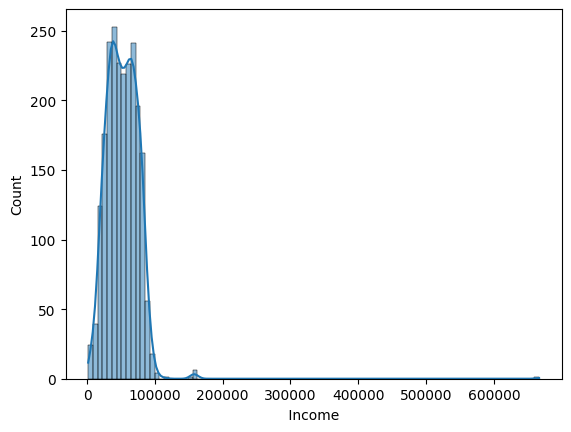

In [44]:
sns.histplot(df[' Income '], kde=True)


(array([1.654e+03, 5.540e+02, 7.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([  1730. ,  68223.6, 134717.2, 201210.8, 267704.4, 334198. ,
        400691.6, 467185.2, 533678.8, 600172.4, 666666. ]),
 <BarContainer object of 10 artists>)

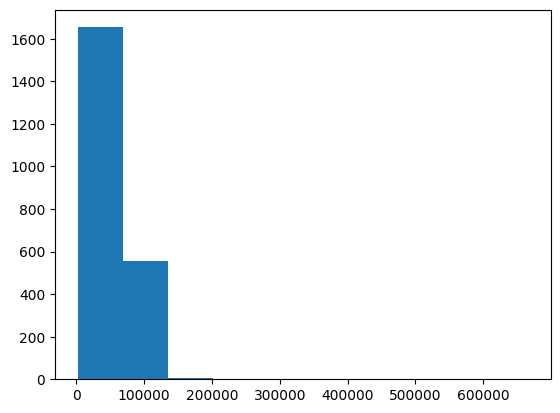

In [45]:
# it has outlier
plt.hist(df[' Income '])

In [46]:
df[' Income '].dtype

dtype('float64')

In [47]:
df[' Income '].max

<bound method Series.max of 0       84835.0
1       57091.0
2       67267.0
3       32474.0
4       21474.0
         ...   
2235    66476.0
2236    31056.0
2237    46310.0
2238    65819.0
2239    94871.0
Name:  Income , Length: 2240, dtype: float64>

check the range of income

(array([ 242.,  818., 1143.,    5.,    0.,    7.,    0.]),
 array([     0.,  25000.,  50000., 100000., 125000., 150000., 175000.,
        200000.]),
 <BarContainer object of 7 artists>)

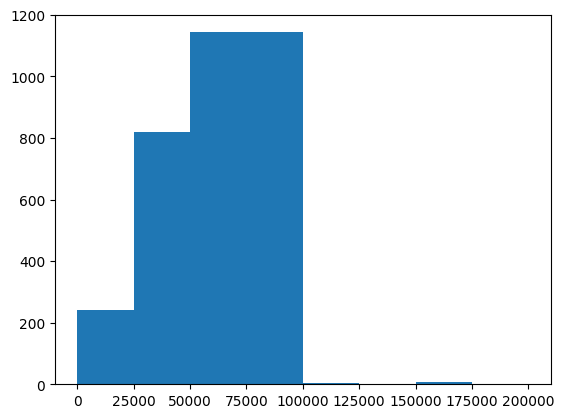

In [48]:
plt.hist(df[' Income '],bins=[0,25000,50000, 100000,125000,150000,175000,200000]) 

Fill the missing income data based on the Education mean

First we calculate mean and median of Income based on the Education by grouping data based on Educations 

In [49]:
df.groupby('Education')[' Income '].mean()

Education
2n Cycle      47633.190000
Basic         20306.259259
Graduation    52720.373656
Master        52917.534247
PhD           56145.313929
Name:  Income , dtype: float64

In [52]:
df.groupby('Education')[' Income '].median()

Education
2n Cycle      46805.0
Basic         20744.0
Graduation    52028.5
Master        50943.0
PhD           55212.0
Name:  Income , dtype: float64

After plotting scatter plot plt.scatter(df['Year_Birth'],df[' Income ']) we found Income has outlier 

In [53]:
# outlier detection by removing edge cases 0.01 and 0.99 
q1= df[' Income '].quantile(0.01)
q99= df[' Income '].quantile(0.99)

df[' Income ']= df[' Income '].clip(lower=q1, upper=q99)

In [54]:
df.groupby('Education')[' Income '].mean()

Education
2n Cycle      47624.333000
Basic         20309.192593
Graduation    52089.920251
Master        52723.528219
PhD           55561.189605
Name:  Income , dtype: float64

In [55]:
df.groupby('Education')[' Income '].median()

Education
2n Cycle      46805.0
Basic         20744.0
Graduation    52028.5
Master        50943.0
PhD           55212.0
Name:  Income , dtype: float64

Fill all missing values based after removing outlier

In [56]:
df[' Income '] = df.groupby('Education')[' Income '].transform(lambda x : x.fillna(x.median()))

In [57]:
df[' Income '].isna().sum()

np.int64(0)

show relation between Income and Year_Birth

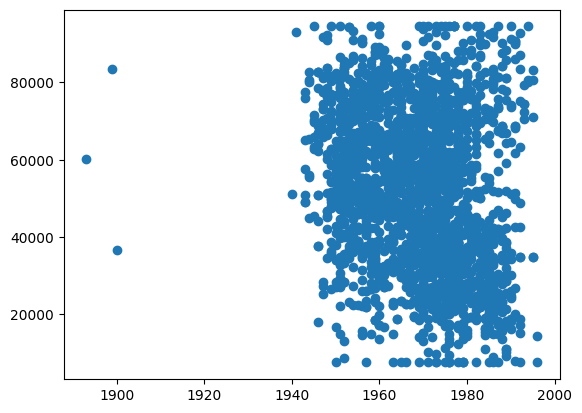

In [58]:
plt.scatter(df['Year_Birth'],df[' Income '])

(array([ 69., 173., 255., 312., 294., 288., 291., 261., 211.,  86.]),
 array([ 7579.2 , 16267.16, 24955.12, 33643.08, 42331.04, 51019.  ,
        59706.96, 68394.92, 77082.88, 85770.84, 94458.8 ]),
 <BarContainer object of 10 artists>)

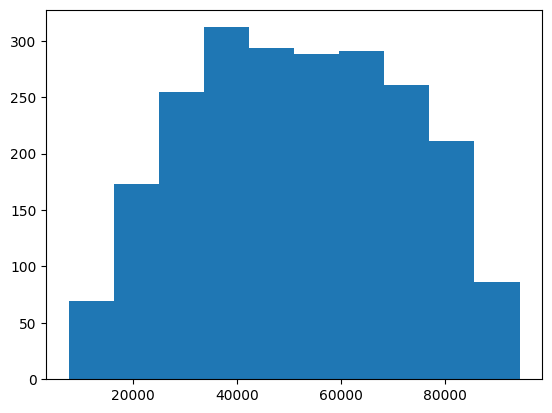

In [59]:
plt.hist(df[' Income '])

QUes : Show how many people are in diff education

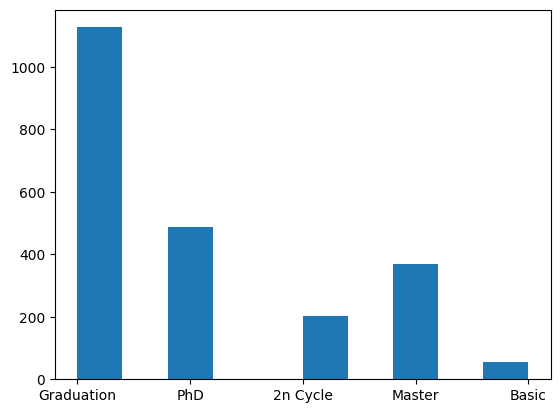

In [60]:
plt.hist(df['Education'])

plt.show()

In [61]:
df['Education'].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

Ques : Is their any relation in Education and Income

In [62]:
df['Country'].value_counts()

Country
SP     1095
SA      337
CA      268
AUS     160
IND     148
GER     120
US      109
ME        3
Name: count, dtype: int64

## GROUP 1 — EASY / FUNDAMENTAL QUESTIONS (LOWER CRITICALITY, GOOD FOR BASICS)

### A. Basic Summary & Exploration

1. 	    What is the distribution of income?
2. 	    What is the average amount spent on Wines?
3. 	    How many customers accepted each campaign?
4. 	    How many customers complained?
5. 	    What is the average web visits per month?
6. 	    What is the average Recency? (Are they still active?)
7. 	    Which product has the lowest spending?
8. 	    What is the distribution of total purchases via Web?
9. 	    How many customers have kids vs teens?
10. 	 What are the top 10 customers with highest total spending?


In [31]:
df= pd.read_csv('../../Data_Files/Project_sample_Data/marketing_data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4    Income              2216 non-null   object
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Dt_Customer          2240 non-null   object
 8   Recency              2240 non-null   int64 
 9   MntWines             2240 non-null   int64 
 10  MntFruits            2240 non-null   int64 
 11  MntMeatProducts      2240 non-null   int64 
 12  MntFishProducts      2240 non-null   int64 
 13  MntSweetProducts     2240 non-null   int64 
 14  MntGoldProds         2240 non-null   int64 
 15  NumDealsPurchases    2240 non-null   int64 
 16  NumWeb

### 1.	👉 What is the distribution of income

In [32]:
# 51. What is the distribution of income
    # 👉 “How does the Income column look in terms of range, shape, and pattern?”
    # In other words, it wants you to check: 
        # Are most customers low-income?
        # Are they medium-income? 
        # Are there very high-income customers? 
        # Is the income spread evenly or is it skewed?  
        # Does the dataset contain outliers (e.g., extremely high incomes)? 
        # What is the minimum, maximum, average income? 
        # Does the distribution look normal, left-skewed, or right-skewed?
        # normal skewed - even spread 
        # left-skewed - small group earns below $X but most earn high income
        # right-skewed - meaning most customers earn below ₹X but a small group earns much higher

{'whiskers': [<matplotlib.lines.Line2D at 0x27e8ebc4b90>,
 'caps': [<matplotlib.lines.Line2D at 0x27e8ebc5190>,
 'boxes': [<matplotlib.lines.Line2D at 0x27e8ebc48c0>],
 'medians': [<matplotlib.lines.Line2D at 0x27e8ebc55b0>],
 'fliers': [<matplotlib.lines.Line2D at 0x27e8ebc5940>],
 'means': []}

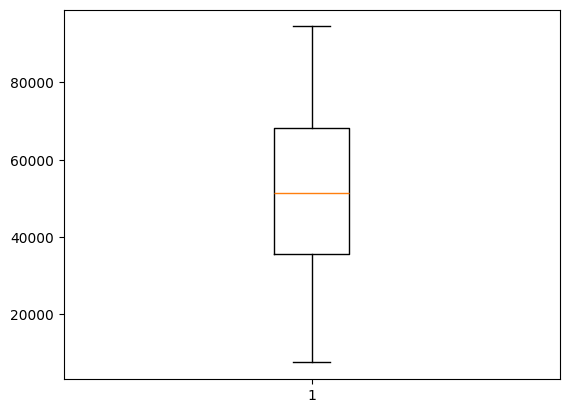

In [83]:
plt.boxplot(x=df[' Income ']) 

### 8. 	   👉  What is the distribution of total purchases via Web?

<Axes: xlabel='NumWebPurchases', ylabel='Count'>

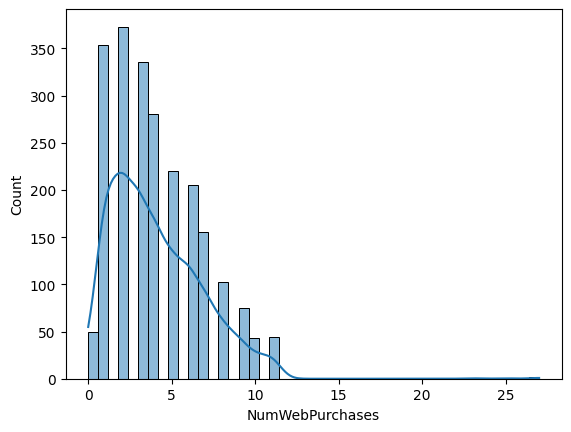

In [ ]:
sns.histplot(df['NumWebPurchases'],kde=True) 

<Axes: xlabel='NumWebPurchases'>

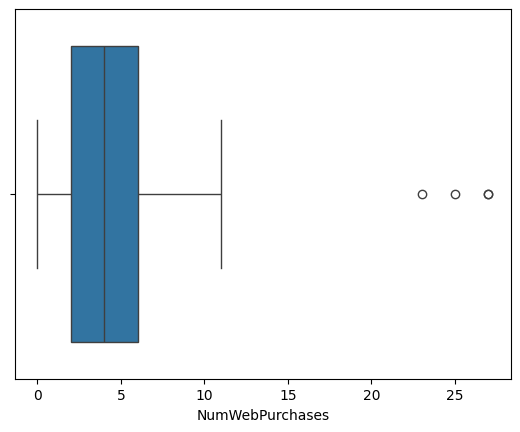

In [ ]:
# outlier detection - sns.boxplot()
sns.boxplot(x=df['NumWebPurchases'])

# can see outlier present, extreme high very few people purchase web online very high

In [ ]:
## max and min, 1% 99% 
print(f" Max value : {df['NumWebPurchases'].max()}")
print(f" Min value : {df['NumWebPurchases'].min()}")
print(f"1 perc data  : {df['NumWebPurchases'].quantile(.01)}") 
print(f"99 perc data  : {df['NumWebPurchases'].quantile(.96)}") 
q1=df['NumWebPurchases'].quantile(0.01)
q99=df['NumWebPurchases'].quantile(0.99)
# outlier are present : If there are many customers buying 20–30+ times: These are high-value online customers for targeting.
# if want to remove outlier then we can clip(lower=q1, upper=q99)
# df['NumWebPurchases'] = df['NumWebPurchases'].clip(lower=q1, upper=q99)


 Max value : 27
 Min value : 0
1 perc data  : 0.0
99 perc data  : 10.0


In [ ]:
df['Sorted_NumWebPurchases']=df['NumWebPurchases'].clip(lower=q1, upper=q99)

In [ ]:
df['Sorted_NumWebPurchases'].head()

0    4
1    7
2    3
3    1
4    3
Name: Sorted_NumWebPurchases, dtype: int64

In [ ]:
## Mean, median mode
df['Sorted_NumWebPurchases'].describe()

count    2240.000000
mean        4.058929
std         2.642307
min         0.000000
25%         2.000000
50%         4.000000
75%         6.000000
max        11.000000
Name: Sorted_NumWebPurchases, dtype: float64

In [ ]:
df['Sorted_NumWebPurchases'].median()

np.float64(4.0)

In [ ]:
df['Sorted_NumWebPurchases'].mode()

0    2
Name: Sorted_NumWebPurchases, dtype: int64

<Axes: xlabel='Sorted_NumWebPurchases'>

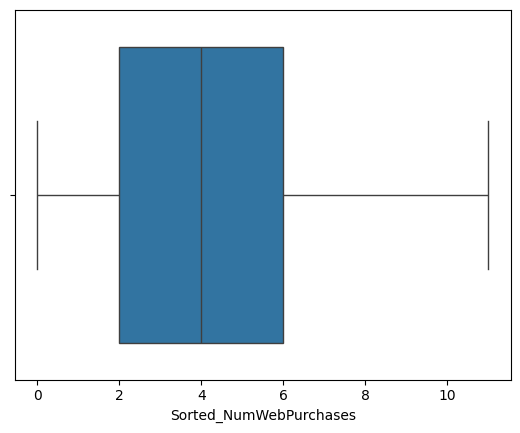

In [ ]:
# distribution become steady  no outlier
sns.boxplot(x=df['Sorted_NumWebPurchases'])

<Axes: xlabel='Sorted_NumWebPurchases', ylabel='Count'>

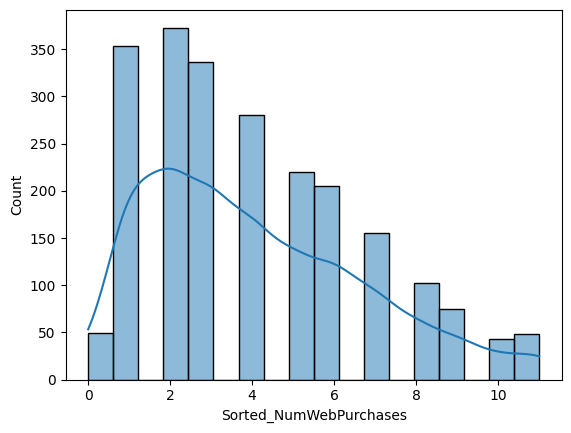

In [ ]:
# ⭐ . Segmentation Perspective
# it shows the diswtribution is left-skewed = meaning large number of cust purchase from web very few times and 20-30 percentage of people purchase product online very frequently 
#  From distribution patterns, you can segment customers:
    # Low Web Buyers (0–3 purchases) = Need promotions, discounts
    # Medium Buyers (4–6 purchases) = Growing digital customers
    # High Web Buyers (7-10 purchases) = high users 
    # premium Web buyers (11+ purchase) = premium users → Upsell opportunities
sns.histplot(df['Sorted_NumWebPurchases'], kde=True)

In [ ]:
# ⭐ 5. Channel Strategy Insights for Company - Left skewed 
# Based on distribution:
    # ✔ If most values = 0–2
        # → Website is weak
        # → Need better UX, offers, email campaigns
    # ✔ If most values = 5–10
        # → Website is important
        # → Need to optimize for retention
    # ✔ Long right tail 
        # → Few customers are loyal online → Grow this base

# ⭐  Interpretation:
    # Website is used by many customers but not frequently
    # A small group is highly active
    # Personalized marketing should target high-frequency buyers
    # Advertising budgets can prioritize converting low-frequency buyers

<Axes: xlabel='NumStorePurchases'>

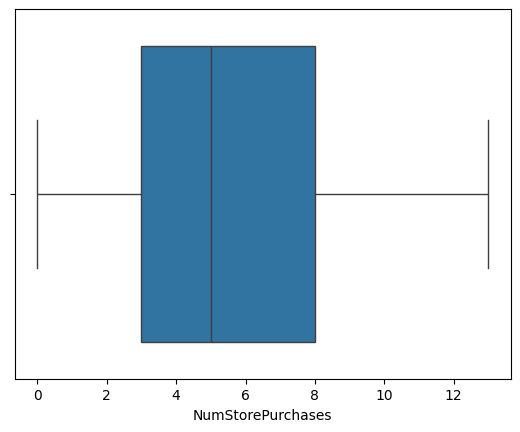

In [ ]:
sns.boxplot(x=df['NumStorePurchases'])

<Axes: xlabel='NumStorePurchases', ylabel='Count'>

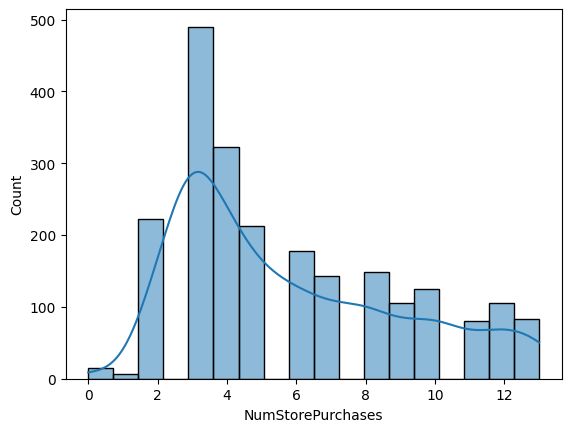

In [ ]:
sns.histplot(df['NumStorePurchases'], kde=True)

<Axes: xlabel='NumCatalogPurchases'>

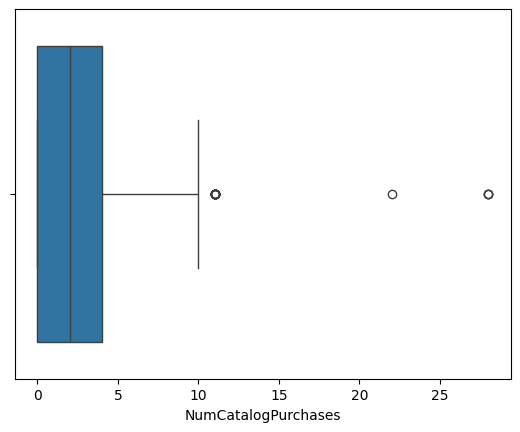

In [ ]:
sns.boxplot(x=df['NumCatalogPurchases'])

In [ ]:
q1= df['NumCatalogPurchases'].quantile(0.01)
q99= df['NumCatalogPurchases'].quantile(0.98)
print(q99)
df['Sorted_NumCatalogPurchases']= df['NumCatalogPurchases'].clip(lower=q1, upper=q99)

10.0


<Axes: xlabel='Sorted_NumCatalogPurchases'>

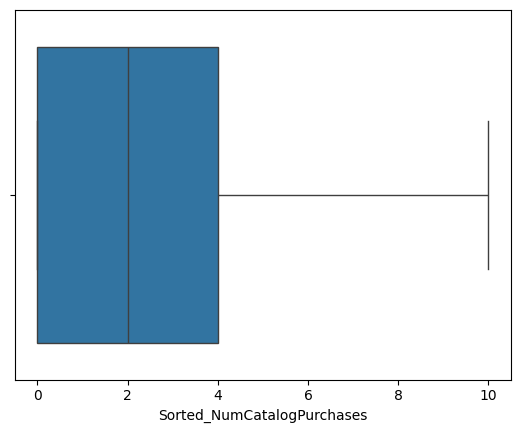

In [ ]:
sns.boxplot(x=df['Sorted_NumCatalogPurchases'])

<Axes: xlabel='Sorted_NumCatalogPurchases', ylabel='Count'>

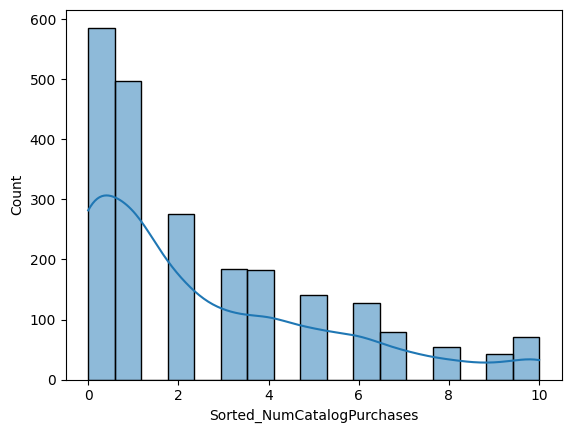

In [ ]:
sns.histplot(df['Sorted_NumCatalogPurchases'], kde=True)

<Axes: xlabel='NumCatalogPurchases', ylabel='Count'>

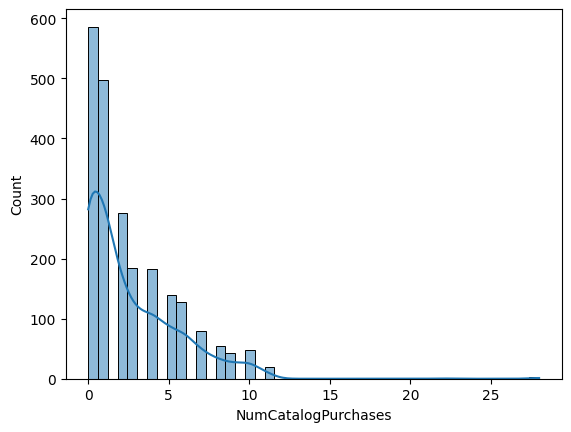

In [ ]:
sns.histplot(df['NumCatalogPurchases'], kde=True)

## 👉 What are the top 10 customers with highest total spending?

In [85]:
# Step 1: Understand What “Total Spending” Means

    # In this dataset, customer purchases are split across 6 categories:
        # MntWines
        # MntFruits
        # MntMeatProducts
        # MntFishProducts
        # MntSweetProducts
        # MntGoldProds
        # TotalSpend = sum of all product category amounts
df['TotalSpend']= df[['MntWines','MntFruits','MntMeatProducts',
                       'MntFishProducts','MntSweetProducts',
                       'MntGoldProds']].sum(axis=1)


In [86]:
## actual Age of customer 
df['Cust_Age']= 2025 - df['Year_Birth'] 

In [87]:
## Top 10 customer with highest total spending
top_cust = df.sort_values(by='TotalSpend', ascending=False).head(10)
top_cust

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,TotalSpend,Cust_Age
672,5350,1991,Master,Single,90638.0,0,0,2/13/14,29,1156,...,0,0,1,0,0,1,0,SA,2525,34
671,5735,1991,Master,Single,90638.0,0,0,2/13/14,29,1156,...,0,0,1,0,0,0,0,SP,2525,34
1404,1763,1988,Graduation,Together,87679.0,0,0,7/27/13,62,1259,...,1,0,1,1,0,1,0,CA,2524,37
1026,4580,1969,Graduation,Married,75759.0,0,0,10/25/13,46,1394,...,1,0,1,1,0,1,0,SA,2486,56
1864,4475,1949,PhD,Married,69098.0,0,0,2/16/13,82,1315,...,0,0,0,0,0,0,0,SP,2440,76
607,5453,1956,Master,Married,90226.0,0,0,9/26/12,26,1083,...,0,0,0,1,0,0,0,SA,2352,69
376,10133,1970,Graduation,Single,93790.0,0,0,2/12/14,16,1302,...,0,1,1,1,0,1,0,CA,2349,55
1811,9010,1972,Master,Married,83151.0,0,0,2/10/13,80,968,...,1,0,1,1,0,1,0,SP,2346,53
1409,6024,1953,Graduation,Together,94384.0,0,0,3/4/13,62,1111,...,0,1,1,1,0,1,0,SP,2302,72
1408,5386,1953,Graduation,Together,94384.0,0,0,3/4/13,62,1111,...,0,1,1,1,0,1,0,SA,2302,72


In [ ]:
# Step 4: Extract Business Insights 
    # 1️⃣ How old are these top customers?
        # → Do high-value customers belong to specific age groups?
    # 2️⃣ Income Profile
        # → Are top spenders also high-income?
        # → Sometimes No (loyalty > income)
    # 3️⃣ Family Structure
        # → Do they have kids?
        # → Families often spend more on food categories.
    # 4️⃣ Preferred Category
        # → Among top 10:
        # Do they buy more wine?
        # Or more meat/fish?
    # 5️⃣ Marketing Campaign Acceptance
        # → Did they respond to campaigns?
        # → Important for targeting.
    # 6️⃣ Channel Preference
        # → Do they shop online (NumWebPurchases)?
        # → Or in-store (NumStorePurchases)?
    # 7️⃣ Website Visits
        # → Do top spenders visit the website more?

# Finding	                             Marketing Action
# Top customers = high income	     👉    Push luxury items
# Top customers = high wine spenders 👉     Launch wine bundles
# Top customers buy in-store	     👉    Provide store coupons
# Top customers accept campaigns	 👉    Target them aggressively
# Top customers don’t accept	     👉    Build new personalized campaigns

In [91]:
# 1️⃣ How old are these top customers?
top_cust.groupby(pd.qcut(df['Cust_Age'],4),observed=False)['TotalSpend'].mean()

Cust_Age
(28.999, 48.0]    2524.666667
(48.0, 55.0]      2347.500000
(55.0, 66.0]      2486.000000
(66.0, 132.0]     2349.000000
Name: TotalSpend, dtype: float64

In [100]:
# 
df.sort_values(by='TotalSpend', ascending=False)['TotalSpend'].head(10)

672     2525
671     2525
1404    2524
1026    2486
1864    2440
607     2352
376     2349
1811    2346
1409    2302
1408    2302
Name: TotalSpend, dtype: int64

In [102]:
sum_top10= df.sort_values(by='TotalSpend', ascending=False)['TotalSpend'].head(10).sum()
sum_top10

np.int64(24151)

In [104]:
df['TotalSpend'].sum()

np.int64(1356988)

In [ ]:
# What percentage of revenue they contribute? 
per= (sum_top10 / (df['TotalSpend'].sum())) * 100
per

np.float64(1.779750447314199)

## 👉 How many customers accepted each campaign?

In [65]:
# 🧠 Step-3: Business Insights You Can Generate
# Once you get the counts, analyse like a marketing expert:
    # ✔ Which campaign had the highest acceptance?
        # → Shows high product-market fit.
    # ✔ Which campaign had the lowest acceptance?
        # → Needs redesign or targeting.
    # ✔ Compare “Response” (latest campaign) with older campaigns
        # → Are campaigns improving over time?
    # ✔ Did frequent web visitors accept more?
        # → Important for digital marketing strategy.
    # ✔ Do high-income customers accept more?
        # → Helps in premium product targeting.

campaign_group=['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5']
accepted_counts =df[campaign_group].sum()
accepted_counts 

AcceptedCmp1    144
AcceptedCmp2     30
AcceptedCmp3    163
AcceptedCmp4    167
AcceptedCmp5    163
dtype: int64

<Axes: >

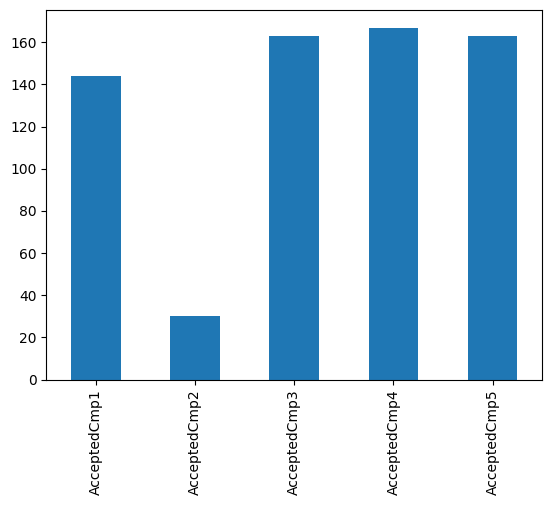

In [66]:
accepted_counts.plot(kind='bar')

### Business Insights You Can Generate

### 1️⃣ Campaign acceptance by income group

In [69]:
# 1️⃣ Campaign acceptance by income group
df.groupby(pd.qcut(df[' Income '], 4),observed=False)['AcceptedCmp1'].mean()*100

 Income 
(7579.199, 35538.75]     0.000000
(35538.75, 51498.5]      0.714286
(51498.5, 68289.75]      3.392857
(68289.75, 94458.8]     21.607143
Name: AcceptedCmp1, dtype: float64

In [70]:
df.groupby(pd.qcut(df[' Income '], 4),observed=False)['AcceptedCmp2'].mean()*100

 Income 
(7579.199, 35538.75]    0.000000
(35538.75, 51498.5]     0.714286
(51498.5, 68289.75]     1.785714
(68289.75, 94458.8]     2.857143
Name: AcceptedCmp2, dtype: float64

In [71]:
df.groupby(pd.qcut(df[' Income '], 4),observed=False)['AcceptedCmp3'].mean()*100

 Income 
(7579.199, 35538.75]    7.678571
(35538.75, 51498.5]     8.750000
(51498.5, 68289.75]     5.000000
(68289.75, 94458.8]     7.678571
Name: AcceptedCmp3, dtype: float64

In [72]:
df.groupby(pd.qcut(df[' Income '], 4),observed=False)['AcceptedCmp4'].mean()*100

 Income 
(7579.199, 35538.75]     0.178571
(35538.75, 51498.5]      4.107143
(51498.5, 68289.75]     11.785714
(68289.75, 94458.8]     13.750000
Name: AcceptedCmp4, dtype: float64

In [78]:
df.groupby(pd.qcut(df[' Income '], 4),observed=False)['AcceptedCmp5'].mean()*100

 Income 
(7579.199, 35538.75]     0.000000
(35538.75, 51498.5]      0.178571
(51498.5, 68289.75]      1.607143
(68289.75, 94458.8]     27.321429
Name: AcceptedCmp5, dtype: float64

### 2️⃣ Campaign acceptance by marital status

In [81]:
# 2️⃣ Campaign acceptance by marital status
df.groupby(df['Marital_Status'])['AcceptedCmp1'].mean()* 100


Marital_Status
Absurd      50.000000
Alone        0.000000
Divorced     5.172414
Married      7.291667
Single       6.458333
Together     5.517241
Widow        6.493506
YOLO         0.000000
Name: AcceptedCmp1, dtype: float64

<Axes: ylabel='AcceptedCmp1'>

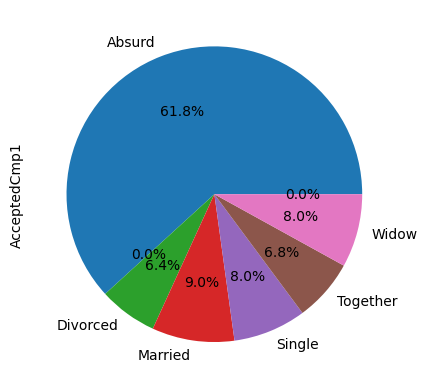

In [82]:
(df.groupby(df['Marital_Status'])['AcceptedCmp1'].mean()* 100).plot(kind='pie',autopct='%0.1f%%' )

In [ ]:
# 3️⃣ Campaign acceptance by product category spend 
    # → Do wine lovers accept more campaigns? 

## GROUP 2 — EDA & INSIGHT QUESTIONS (MODERATE–HIGH CRITICALITY)

### A. Spending Patterns & Product Behavior

### Which product category generates maximum revenue?

In [123]:
total_products=['MntWines','MntFruits','MntMeatProducts',
                       'MntFishProducts','MntSweetProducts',
                       'MntGoldProds']

total_revenew=df[total_products].sum().sort_values(ascending=False)
total_revenew.idxmax, total_revenew.max()

(<bound method Series.idxmax of MntWines            680816
 MntMeatProducts     373968
 MntGoldProds         98609
 MntFishProducts      84057
 MntSweetProducts     60621
 MntFruits            58917
 dtype: int64>,
 np.int64(680816))

<Axes: >

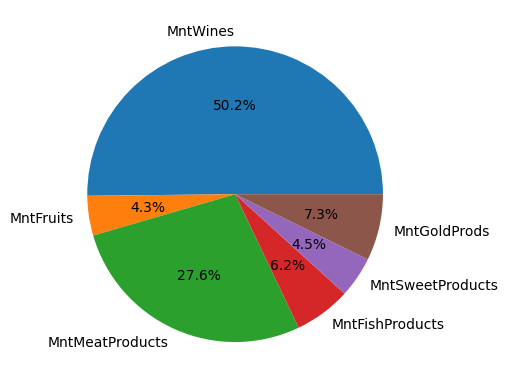

In [114]:
(df[total_products].sum()).plot(kind='pie',autopct='%0.1f%%')

In [127]:
# check where wines purchase more - instore or web
df.groupby(pd.qcut(df['MntWines'],4), observed=False)[['NumStorePurchases','NumWebPurchases']].mean()

,NumStorePurchases,NumWebPurchases
MntWines,,
"(-0.001, 23.75]",2.692857,1.621429
"(23.75, 173.5]",4.192857,3.073214
"(173.5, 504.25]",7.651786,5.533929
"(504.25, 1493.0]",8.623214,6.110714


### What is the correlation between spending on Wines, Meat, Gold, etc.?

<Axes: >

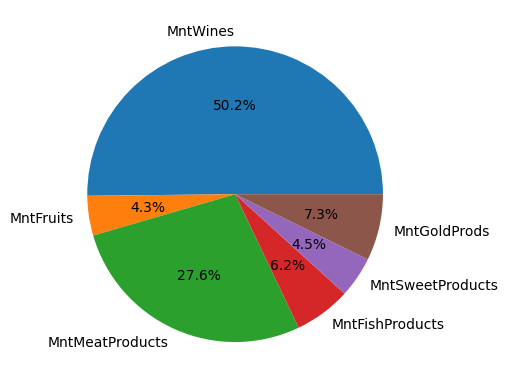

In [120]:
(df[total_products].sum()).plot(kind='pie', autopct='%0.1f%%')

### What is the correlation between spending on Wines, Meat, Gold, etc.?

In [129]:
# create a corelation matrix

product_corr=df[total_products].corr()
product_corr

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
MntWines,1.000000,0.389637,0.562667,0.399753,0.386581,0.387516
MntFruits,0.389637,1.000000,0.543105,0.594804,0.567164,0.392995
MntMeatProducts,0.562667,0.543105,1.000000,0.568402,0.523846,0.350609
MntFishProducts,0.399753,0.594804,0.568402,1.000000,0.579870,0.422875
MntSweetProducts,0.386581,0.567164,0.523846,0.579870,1.000000,0.369724
MntGoldProds,0.387516,0.392995,0.350609,0.422875,0.369724,1.000000


<Axes: >

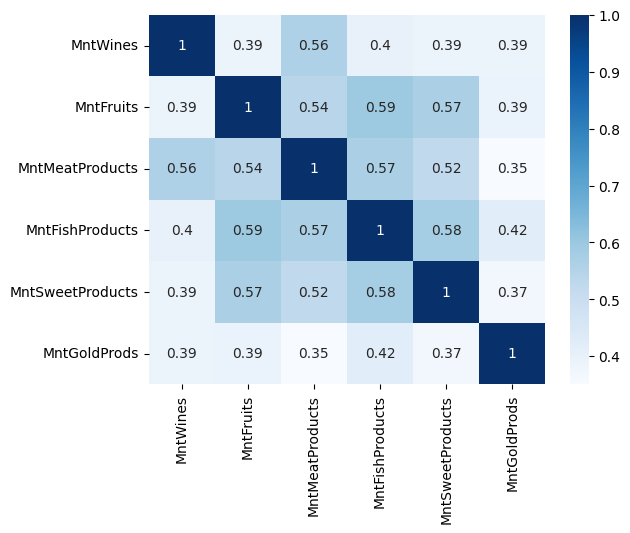

In [131]:
# heatmap
sns.heatmap(product_corr, annot=True, cmap='Blues')

In [ ]:
# 🎯 3. Category Clusters (Marketing Insight)

    # From most datasets of this type, you will see:

        # Cluster	                     Categories	              Customer Type
        # Premium Cluster	        Wines, Meat, Gold, Fish	    High-income, high-value
        # Regular Grocery Cluster	Fruits, Sweets	           Household grocery customers

### Is income strongly correlated with total spending?

In [133]:
df[[' Income ','TotalSpend']].corr()

,Income,TotalSpend
Income,1.000000,0.814058
TotalSpend,0.814058,1.000000
